# M3-B1 — Exploration des 3 sources Acerox

> Notebook d'**exploration rapide** — pas d'EDA fouillée, juste assez pour
> remplir l'inventaire de la note d'identification.

Auteur·rice : Franck — Date : 2026-07-21

**Règles** :
- Pas de transformation (juste lecture, `info`, `head`, `describe`)
- Une cellule markdown par source — qu'est-ce que tu observes ?
- Trace les **risques** et **questions** qui émergent pour l'`identification_sources.md`

In [33]:
from pathlib import Path
import json

import pandas as pd

DATA_DIR = Path("../data")

## Source 1 — Capteurs IoT (CSV)

In [34]:
df_iot = pd.read_csv(DATA_DIR / "capteurs_iot.csv")
df_iot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      51000 non-null  object 
 1   site           51000 non-null  object 
 2   line_id        51000 non-null  int64  
 3   sensor_id      51000 non-null  object 
 4   temperature_c  51000 non-null  float64
 5   vibration_mms  50251 non-null  float64
 6   debit_uh       51000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 2.7+ MB


In [35]:
df_iot.head()

,timestamp,site,line_id,sensor_id,temperature_c,vibration_mms,debit_uh
0,2026-04-14T19:21:43,Lyon,1,SLYO-L1-T01,77.92,5.539793,101.27
1,2026-04-27T02:47:12,Lyon,1,SLYO-L1-T01,70.58,3.361715,110.19
2,2026-04-13T18:18:50,Saint-Etienne,1,SSAI-L1-T01,62.37,4.019277,111.28
3,2026-04-05T10:34:03,Roubaix,2,SROU-L2-T01,66.17,4.922531,123.93
4,2026-04-20T10:18:07,Saint-Etienne,3,SSAI-L3-T01,55.56,1.643043,101.40


In [36]:
df_iot.describe()

,line_id,temperature_c,vibration_mms,debit_uh
count,51000.000000,51000.000000,50251.000000,51000.000000
mean,2.005882,73.717034,4.831502,110.050188
std,1.033472,27.005577,2.685963,11.832749
min,1.000000,26.470000,0.000000,80.000000
25%,1.000000,60.237500,3.302777,102.000000
50%,2.000000,66.090000,4.187726,110.100000
75%,3.000000,72.840000,5.171534,118.050000
max,4.000000,160.000000,12.000000,150.000000


In [45]:
df_iot["site"].value_counts()

site
Roubaix          20570
Saint-Etienne    20248
Lyon             10182
Name: count, dtype: int64

In [46]:
df_iot["line_id"].value_counts()

line_id
1    21980
3    12068
2    11846
4     5106
Name: count, dtype: int64

In [39]:
df_iot["sensor_id"].value_counts()

sensor_id
SLYO-L1-T01    10182
SSAI-L3-T01     6816
SSAI-L1-T01     6760
SSAI-L2-T01     6672
SROU-L3-T01     5252
SROU-L2-T01     5174
SROU-L4-T01     5106
SROU-L1-T01     5038
Name: count, dtype: int64

In [40]:
df_iot.isna().sum()

timestamp          0
site               0
line_id            0
sensor_id          0
temperature_c      0
vibration_mms    749
debit_uh           0
dtype: int64

In [ ]:
df_iot.duplicated().sum()

> 1 000 lignes strictement dupliquées sur 51 000.

> **Observations** :
>
> - Volume : 51 000 lignes × 7 colonnes (~3,6 Mo)
> - Période : du 01 au 29 avr. 2026 (~1 mois), un relevé toutes les ~3-5 min par capteur (8 capteurs, 3 sites, 4 lignes)
> - Qualité observée :
>   - 1 000 lignes strictement dupliquées
>   - `vibration_mms` a 749 valeurs manquantes (NaN) ; les autres colonnes sont complètes (aucun NaN).
>   - Couverture inégale entre sites : Roubaix et Saint-Étienne ont 2× plus de relevés que Lyon, Lyon n’a qu’un seul capteur
>   - LINE-1 a ~4× plus de relevés que LINE-4, les deux autres lignes se situant entre les deux
> - Risques RGPD : pas de données personnelles, mais croisement possbile avec les logs via le timestamp
> - Pertinence métier : très pertinent, car les capteurs (température, vibration, débit) sont les signaux qui permettent de détecter les dérives avant le défaut
> - Question pour Sébastien :
>   - pourquoi un seul capteur à Lyon ?
>   - pourquoi des NaN sur vibration_mms ? panne ou valeurs extrêmes ou filtrées?
>   - la CIBLE ? défaut oui/non liées à ces données
>   - des seuils dans ces données qui sont inquiétants ?

## Source 2 — ERP (JSON)

In [41]:
with (DATA_DIR / "erp_export.json").open() as f:
    orders = json.load(f)
df_erp = pd.DataFrame(orders)
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ordre_id         2000 non-null   int64 
 1   produit_ref      2000 non-null   object
 2   site             2000 non-null   object
 3   line_id          2000 non-null   int64 
 4   date_lancement   2000 non-null   object
 5   date_fin_prevue  2000 non-null   object
 6   statut           2000 non-null   object
 7   ouvrier_id       1891 non-null   object
 8   quantite_kg      2000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 140.8+ KB


In [47]:
df_erp.head()

,ordre_id,produit_ref,site,line_id,date_lancement,date_fin_prevue,statut,ouvrier_id,quantite_kg
0,100000,ALU-T1-22,Roubaix,3,2026-04-01T22:21:08,2026-04-02T23:21:08,suspendu,EMP-5317,3221
1,100001,INOX-316-4,Saint-Etienne,1,2026-04-26T14:52:52,2026-04-28T15:52:52,termine,EMP-7240,4556
2,100002,ALU-T2-18,Saint-Etienne,3,2026-04-11T09:54:06,2026-04-12T16:54:06,suspendu,EMP-1939,1308
3,100003,ALU-T1-22,Roubaix,1,2026-04-20T22:33:08,2026-04-22T04:33:08,termine,EMP-3531,2968
4,100004,ALU-T2-25,Roubaix,4,2026-04-24T01:03:02,2026-04-25T21:03:02,termine,EMP-8778,3278


In [48]:
df_erp.describe(include="all")

,ordre_id,produit_ref,site,line_id,date_lancement,date_fin_prevue,statut,ouvrier_id,quantite_kg
count,2000.000000,2000,2000,2000.000000,2000,2000,2000,1891,2000.000000
unique,NaN,10,2,NaN,1999,1999,4,1689,NaN
top,NaN,INOX-316-4,Roubaix,NaN,2026-04-29T19:55:27,2026-04-14T22:51:14,termine,EMP-4182,NaN
freq,NaN,227,1108,NaN,2,2,1559,4,NaN
mean,100999.500000,NaN,NaN,2.316000,NaN,NaN,NaN,NaN,2528.689000
std,577.494589,NaN,NaN,1.033769,NaN,NaN,NaN,NaN,1425.269007
min,100000.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,51.000000
25%,100499.750000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1270.250000
50%,100999.500000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,2534.000000
75%,101499.250000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,3739.250000


In [51]:
df_erp["statut"].value_counts()

statut
termine     1559
en_cours     197
suspendu     139
annule       105
Name: count, dtype: int64

In [52]:
df_erp["ouvrier_id"].isna().sum(), df_erp["ouvrier_id"].nunique()

(109, 1689)

In [53]:
df_erp.isna().sum()

ordre_id             0
produit_ref          0
site                 0
line_id              0
date_lancement       0
date_fin_prevue      0
statut               0
ouvrier_id         109
quantite_kg          0
dtype: int64

In [ ]:
df_erp.duplicated().sum()

> Aucun doublon (0 ligne dupliquée, `ordre_id` tous uniques).

> **Observations** :
>
> - Volume : 2 000 ordres × 9 colonnes (~545 Ko)
> - Période : du 01 au 29 avr. 2026 (~1 mois), événementiel ~70 ordres lancés/jour
> - Qualité observée :
>   - aucun doublon
>   - `statut` déséquilibré : `termine` domine (1 559), les autres sont marginaux — `en_cours` 197, `suspendu` 139, `annule` 105
>   - 109 ordres n’ont pas d’ouvrier renseigné (donnée manquante sur `ouvrier_id`)
> - ⚠️ Risque RGPD : `ouvrier_id` identifie nommément un employé → donnée personnelle = cœur du risque (si on croise avec le fichier employés)
> - Pertinence métier : contexte de production, permet d'enrichir le modèle via croismenet avce les données du CSV via site, line_id et le timestamp
> - Question pour Sébastien : pourquoi 109 ordres n’ont-ils pas d’`ouvrier_id` ?

## Source 3 — Logs machines (texte)

In [43]:
log_path = DATA_DIR / "logs_machines.log"
n_lines = sum(1 for _ in log_path.open())
print(f"Nombre de lignes : {n_lines:,}")
print(f"Taille fichier : {log_path.stat().st_size / 1024:.1f} Ko")

# Aperçu des 5 premières lignes
with log_path.open() as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

Nombre de lignes : 30,000
Taille fichier : 1872.8 Ko
[2026-04-01T00:00:16] Lyon LINE-1 INFO: shift_changed
[2026-04-01T00:01:07] Saint-Etienne LINE-2 INFO: operator_login
[2026-04-01T00:01:34] Saint-Etienne LINE-3 ERROR: vibration_overlimit sensor=SSAI-L3-T01
[2026-04-01T00:04:18] Roubaix LINE-4 INFO: maintenance_completed
[2026-04-01T00:04:35] Lyon LINE-1 INFO: tooling_loaded


In [54]:
import re

lignes = log_path.read_text().splitlines()
motif = r"\[(?P<ts>[^\]]+)\] (?P<site>\S+) (?P<line>LINE-\d+) (?P<level>INFO|WARN|ERROR): (?P<event>\w+)"
df_logs = pd.Series(lignes).str.extract(motif)
df_logs["ts"] = pd.to_datetime(df_logs["ts"])
df_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ts      30000 non-null  datetime64[ns]
 1   site    30000 non-null  object        
 2   line    30000 non-null  object        
 3   level   30000 non-null  object        
 4   event   30000 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 1.1+ MB


In [55]:
df_logs.head()

,ts,site,line,level,event
0,2026-04-01 00:00:16,Lyon,LINE-1,INFO,shift_changed
1,2026-04-01 00:01:07,Saint-Etienne,LINE-2,INFO,operator_login
2,2026-04-01 00:01:34,Saint-Etienne,LINE-3,ERROR,vibration_overlimit
3,2026-04-01 00:04:18,Roubaix,LINE-4,INFO,maintenance_completed
4,2026-04-01 00:04:35,Lyon,LINE-1,INFO,tooling_loaded


In [ ]:
pd.Series(lignes).duplicated().sum()

> 1 ligne strictement dupliquée sur 30 000.

In [57]:
df_logs["level"].value_counts()

level
INFO     22501
WARN      5758
ERROR     1741
Name: count, dtype: int64

In [58]:
df_logs["event"].value_counts()

event
operator_login                    4615
maintenance_completed             4501
machine_started                   4488
shift_changed                     4473
tooling_loaded                    4424
vibration_threshold_approached    1443
temperature_drift_detected        1442
lubricant_low                     1440
throughput_below_target           1433
communication_lost                 468
temperature_critical               434
emergency_stop                     425
vibration_overlimit                414
Name: count, dtype: int64

In [60]:
# pics : nb d'ERROR par jour
df_logs[df_logs["level"] == "ERROR"].groupby(df_logs["ts"].dt.date).size()

ts
2026-04-01    72
2026-04-02    67
2026-04-03    59
2026-04-04    59
2026-04-05    54
2026-04-06    63
2026-04-07    55
2026-04-08    60
2026-04-09    50
2026-04-10    55
2026-04-11    68
2026-04-12    60
2026-04-13    69
2026-04-14    54
2026-04-15    65
2026-04-16    52
2026-04-17    65
2026-04-18    50
2026-04-19    53
2026-04-20    51
2026-04-21    59
2026-04-22    59
2026-04-23    58
2026-04-24    74
2026-04-25    58
2026-04-26    54
2026-04-27    64
2026-04-28    71
2026-04-29    63
dtype: int64

> **Observations** :
>
> - Format : `[timestamp] site LINE-x NIVEAU: event` (+ parfois `sensor=` ou `reason=`)
> - Parsing nécessaire : texte brut → à parser (regex) en tableau (colonnes ts, site, line, level, event) avant exploitation
> - Qualité observée :
>   - 1 seule ligne dupliquée
>   - majorité d’INFO (22 501), moins de WARN (5 758), quelques ERROR (1 741)
>   - nb d’ERROR par jour constant (~60/jour, min 50 / max 74) — aucun pic sur la période
> - Risque RGPD : aucun identifiant employé en propre (pas de `EMP-`) ; risque seulement au croisement (`operator_login` horodaté sur une ligne + `ouvrier_id` de l’ERP au même moment → ré-identification possible)
> - Croisement avec les capteurs IoT (corrélation Roubaix line 3 ?) : confirmé — Roubaix LINE-3 concentre 598 ERROR (le plus élevé) et sa vibration moyenne est ~12 mm/s vs ~4 mm/s ailleurs (3×). La ligne qui vibre anormalement est celle qui génère le plus d’erreurs → signal avant-coureur exploitable en préventif

### Types d'événements par niveau

- **INFO**
  - `operator_login`
  - `maintenance_completed`
  - `machine_started`
  - `shift_changed`
  - `tooling_loaded`
- **WARN**
  - `vibration_threshold_approached`
  - `temperature_drift_detected`
  - `lubricant_low`
  - `throughput_below_target`
- **ERROR**
  - `communication_lost`
  - `temperature_critical`
  - `emergency_stop`
  - `vibration_overlimit`

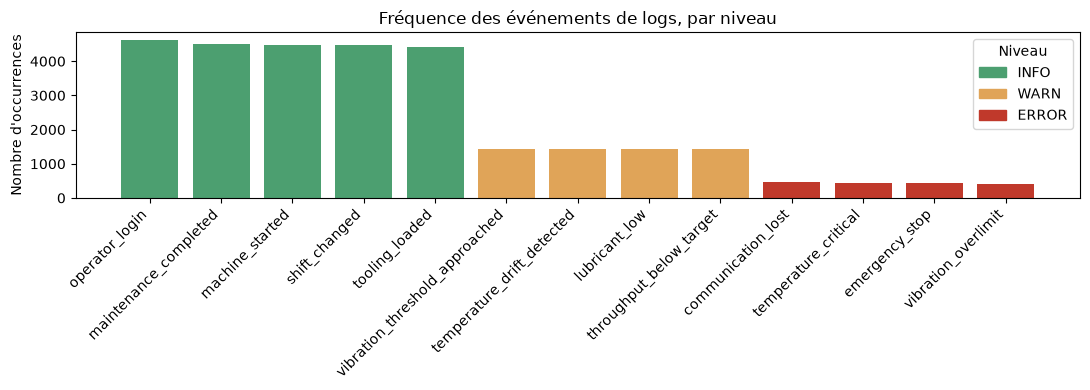

In [63]:
import matplotlib.pyplot as plt

niveaux = ["INFO", "WARN", "ERROR"]
couleurs = {"INFO": "#4c9f70", "WARN": "#e0a458", "ERROR": "#c0392b"}

# Bar chart des fréquences, événements groupés et colorés par niveau
freq = df_logs.groupby("level")["event"].value_counts().reindex(niveaux, level=0)
labels = [event for _, event in freq.index]
colors = [couleurs[level] for level, _ in freq.index]

plt.figure(figsize=(11, 4))
plt.bar(labels, freq.values, color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre d'occurrences")
plt.title("Fréquence des événements de logs, par niveau")
handles = [plt.Rectangle((0, 0), 1, 1, color=couleurs[l]) for l in niveaux]
plt.legend(handles, niveaux, title="Niveau")
plt.tight_layout()
plt.show()

In [64]:
roubaix_l3 = df_iot[(df_iot["site"] == "Roubaix") & (df_iot["line_id"] == 3)]["vibration_mms"]
roubaix_l3.describe()

count    5194.0
mean       12.0
std         0.0
min        12.0
25%        12.0
50%        12.0
75%        12.0
max        12.0
Name: vibration_mms, dtype: float64

> Capteur Roubaix L3 défaillant : vibration figée à 12.0 (écart-type 0, valeur = max du dataset).

## Synthèse pour `identification_sources.md`

Remplis le tableau d'inventaire dans `../identification_sources.md` à
partir des observations ci-dessus.